# **Autocorrelation & Lag 30**

Notebook ini bertujuan untuk mengubah dataset hasil crawling konsentrasi NO₂ di Kwanyar menjadi bentuk supervised learning dengan membuat 30 fitur lag (NO₂ pada hari-hari sebelumnya).
Dataset ini akan digunakan pada tahap modeling di notebook knnRegression.ipynb.


# **IMPORT LIBRARY**

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np

# Menampilkan versi library (opsional)
print("Pandas version:", pd.__version__)


Pandas version: 2.3.1


# **Load Dataset**

In [2]:
# Pastikan file hasil crawling tersedia
data_path = "data/NO2_Kwanyar.csv"  

# Baca dataset
df_raw = pd.read_csv(data_path)
print("✅ Dataset berhasil dimuat.")
df_raw.head()


✅ Dataset berhasil dimuat.


,Tanggal,NO2
0,2023-01-01,NaN
1,2023-01-02,NaN
2,2023-01-03,NaN
3,2023-01-04,0.000034
4,2023-01-05,0.000031


## **Mengecek Struktur dan Kualitas Data**
Sebelum melakukan pembuatan lag, kita perlu memastikan bahwa:
- Tidak ada nilai kosong (`NaN`)
- kalau ada handling Missing Values
- Kolom waktu sudah dalam format tanggal
- Kolom target (NO₂) bertipe numerik


In [3]:
# Cek tipe data dan missing values
df_raw.info()
print("\nJumlah nilai kosong per kolom:\n", df_raw.isnull().sum())

# Jika kolom tanggal belum dalam format datetime
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'])

# Pastikan data diurutkan berdasarkan waktu
df_raw = df_raw.sort_values('Tanggal').reset_index(drop=True)

# Interpolasi linear
df_raw['NO2'] = df_raw['NO2'].interpolate(method='linear')

# Isi NaN sisa di awal/akhir data
df_raw['NO2'] = df_raw['NO2'].bfill().ffill()

# Cek ulang hasilnya
print("Nilai kosong setelah semua proses:\n", df_raw.isnull().sum())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tanggal  1016 non-null   object 
 1   NO2      516 non-null    float64
dtypes: float64(1), object(1)
memory usage: 16.0+ KB

Jumlah nilai kosong per kolom:
 Tanggal      0
NO2        500
dtype: int64
Nilai kosong setelah semua proses:
 Tanggal    0
NO2        0
dtype: int64


## **Deteksi dan Penanganan Outlier**

Sebelum melanjutkan ke pembuatan *lag*, dilakukan tahap deteksi dan penanganan **outlier**  
pada kolom `NO2`. Tujuannya adalah memastikan bahwa nilai ekstrim tidak memengaruhi  
hasil model KNN Regression nantinya.

Metode yang digunakan:
- **IQR (Interquartile Range)**  
  Outlier didefinisikan sebagai nilai yang berada di bawah `Q1 - 1.5*IQR`  
  atau di atas `Q3 + 1.5*IQR`.  

Penanganan dilakukan dengan **winsorization**, yaitu mengganti outlier  
dengan nilai batas bawah dan atas agar distribusi tetap stabil.


Q1 = 0.000014, Q3 = 0.000030, IQR = 0.000016
Batas bawah = -0.000010, Batas atas = 0.000055
Jumlah outlier terdeteksi: 19


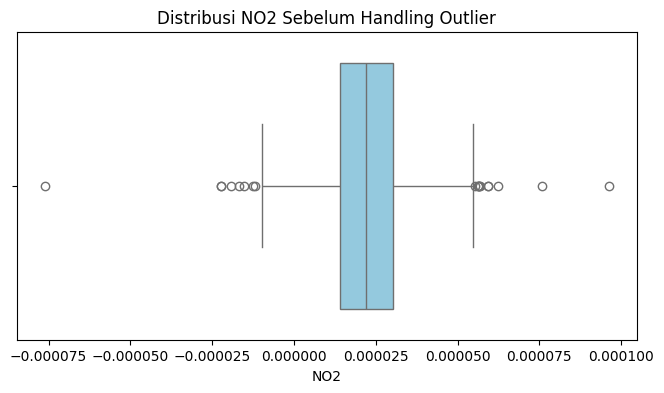

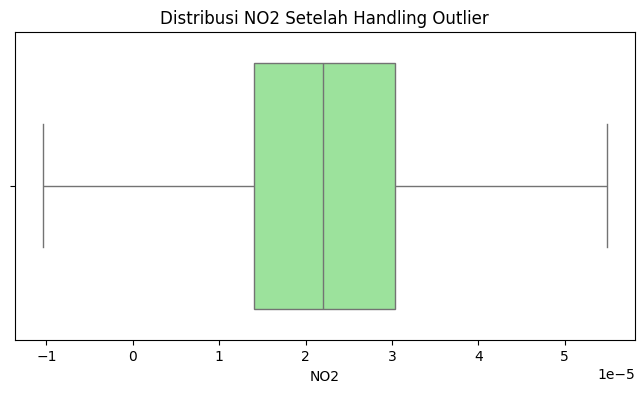

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Salin data hasil pembersihan missing values
df_clean = df_raw.copy()

# Hitung Q1, Q3, dan IQR
Q1 = df_clean["NO2"].quantile(0.25)
Q3 = df_clean["NO2"].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.6f}, Q3 = {Q3:.6f}, IQR = {IQR:.6f}")
print(f"Batas bawah = {lower_bound:.6f}, Batas atas = {upper_bound:.6f}")

# Deteksi outlier
outliers = df_clean[(df_clean["NO2"] < lower_bound) | (df_clean["NO2"] > upper_bound)]
print(f"Jumlah outlier terdeteksi: {len(outliers)}")

# Visualisasi sebelum handling
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["NO2"], color='skyblue')
plt.title("Distribusi NO2 Sebelum Handling Outlier")
plt.show()

# Handling outlier (winsorization)
df_clean["NO2"] = np.where(df_clean["NO2"] < lower_bound, lower_bound, df_clean["NO2"])
df_clean["NO2"] = np.where(df_clean["NO2"] > upper_bound, upper_bound, df_clean["NO2"])

# Visualisasi setelah handling
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["NO2"], color='lightgreen')
plt.title("Distribusi NO2 Setelah Handling Outlier")
plt.show()


### **Hasil Deteksi dan Penanganan Outlier**

Dari visualisasi di atas:
- Sebelum *handling*, terlihat adanya beberapa nilai ekstrim pada kolom `NO2`.
- Setelah dilakukan *winsorization*, distribusi data menjadi lebih stabil  
  tanpa kehilangan banyak informasi penting.

Tahap ini penting untuk mencegah **model KNN Regression** menjadi bias akibat nilai yang terlalu jauh  
dari rata-rata populasi data.


## **Pembuatan Lag 30**
Membuat kolom lag `NO2_lag_1` hingga `NO2_lag_30`.
Setiap kolom berisi nilai NO₂ dari hari-hari sebelumnya untuk keperluan model supervised.


In [5]:
# Membuat 30 kolom lag NO2
max_lag = 30
for i in range(1, max_lag + 1):
    df_raw[f'NO2_lag_{i}'] = df_raw['NO2'].shift(i)

# Drop baris awal yang NaN
df_lag = df_raw.dropna().reset_index(drop=True)
df_lag.head()


,Tanggal,NO2,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_4,NO2_lag_5,NO2_lag_6,NO2_lag_7,NO2_lag_8,...,NO2_lag_21,NO2_lag_22,NO2_lag_23,NO2_lag_24,NO2_lag_25,NO2_lag_26,NO2_lag_27,NO2_lag_28,NO2_lag_29,NO2_lag_30
0,2023-01-31,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,0.000028,0.000027,0.000027,...,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034,0.000034,0.000034,0.000034
1,2023-02-01,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,0.000028,0.000027,...,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034,0.000034,0.000034
2,2023-02-02,0.000033,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,0.000028,...,0.000007,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034,0.000034
3,2023-02-03,0.000034,0.000033,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,...,0.000026,0.000007,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034
4,2023-02-04,0.000034,0.000034,0.000033,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,...,0.000034,0.000026,0.000007,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031


## **Tahap 4: Analisis Autokorelasi**
Langkah ini untuk melihat hubungan antar lag. 
Nilai ACF atau PACF di atas 0.5 menunjukkan korelasi kuat.
Lag dengan korelasi tertinggi akan dijadikan kandidat fitur terbaik untuk KNN Regression.


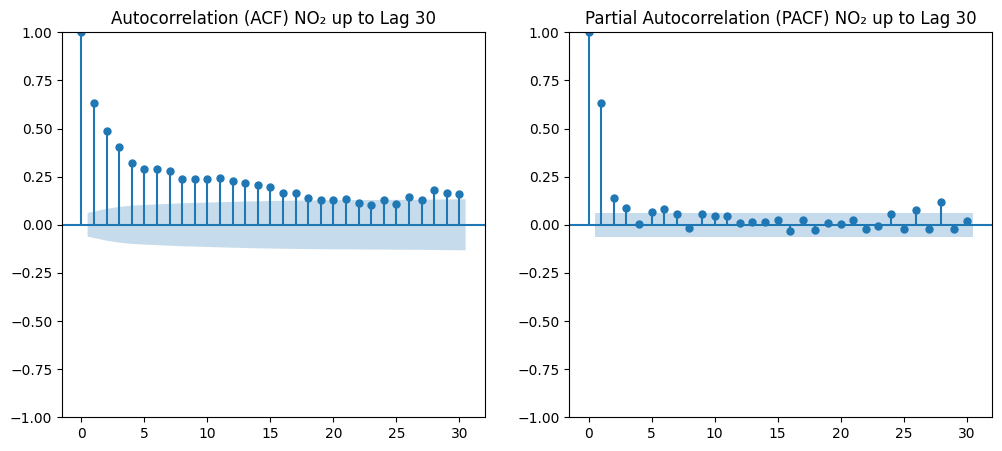

In [6]:
# Import fungsi plot ACF & PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF dan PACF untuk memastikan lag relevan
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(df_raw['NO2'], lags=30, ax=plt.gca())
plt.title("Autocorrelation (ACF) NO₂ up to Lag 30")

plt.subplot(1, 2, 2)
plot_pacf(df_raw['NO2'], lags=30, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation (PACF) NO₂ up to Lag 30")
plt.show()


In [7]:
from statsmodels.tsa.stattools import acf
import pandas as pd

# Hitung autokorelasi hingga lag 30
acf_values = acf(df_raw['NO2'], nlags=30, fft=False)

# Buat DataFrame berisi nilai ACF untuk tiap lag
acf_df = pd.DataFrame({
    'Lag': range(len(acf_values)),
    'ACF_Value': acf_values
})

# Tampilkan hasil awal
acf_df.head(30)

# Filter hanya lag dengan korelasi kuat (> 0.5)
acf_df_filtered = acf_df[(acf_df['Lag'] != 0) & (acf_df['ACF_Value'] > 0.5)]

print("Lag yang memiliki autokorelasi > 0.5:")
print(acf_df_filtered)


Lag yang memiliki autokorelasi > 0.5:
   Lag  ACF_Value
1    1    0.63334


# **Simpan data hasil Lag 30 ke CSV**

In [8]:
# Simpan hasil lag 30
df_lag.to_csv("data/NO2_Kwanyar_Lag30.csv", index=False)
print("✅ Dataset hasil lag 30 disimpan ke 'data/NO2_Kwanyar_Lag30.csv'")


✅ Dataset hasil lag 30 disimpan ke 'data/NO2_Kwanyar_Lag30.csv'
